In [1]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

In [3]:
def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

In [4]:
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

In [5]:
# IC & TO detection
def pi_step_segmentation(force_left, force_right, sampling_rate_pi):
    """
    :param force_left:
    :param force_right:
    :param sampling_rate_pi:
    :return:
    """
    IC_left = pi_ic(force_left, sampling_rate_pi)
    IC_right = pi_ic(force_right, sampling_rate_pi)
    TO_left = pi_to(force_left, IC_left)
    TO_right = pi_to(force_right, IC_right)
    events_dict = {'IC_left': np.array(IC_left[:-1]),
              'IC_right': np.array(IC_right[:-1]),
              'TO_left': np.array(TO_left),
              'TO_right': np.array(TO_right)
    }
    return events_dict

def pi_ic(force_side, sampling_rate):
    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]

    # first IC is when rfd first exceeds 1500 N/s
    IC_side = [rfd_1500[0]]

    # next IC of the same side has to be at least 250 ms away (fs/4)
    for i in range(1, len(rfd_1500)):
        if rfd_1500[i] - rfd_1500[i - 1] > sampling_rate / 4:
            IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

def pi_to(force_side, IC_side):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        TO_side.extend(np.argwhere(force_side[IC+1:] == 0)[0] + IC+1)
    return TO_side

In [6]:
# extract steps and save in dict
def pi_separate_steps(pi_left, pi_right, pi_events):
    """
    separates the Stance phases for each step and save in dict
    :param pi_left: pressure data left foot 3d array shape [31 x 11 x frames]
    :param pi_right: pressure data right foot 3d array shape [31 x 11 x frames]
    :param pi_events: dict with IC and TO indices for each side
    :return pi_steps: dict with data for each step (stance phase) - values 3d array[31 x 11 x [IC:TO]]
    """
    # init dict
    pi_steps = {}

    # left side
    for i in range(len(pi_events['IC_left'])):
        pi_steps['left_'+str(i)]=pi_left[:,:,pi_events['IC_left'][i]:pi_events['TO_left'][i]]
    # right side
    for i in range(len(pi_events['IC_right'])):
        pi_steps['right_'+str(i)]=pi_right[:,:,pi_events['IC_right'][i]:pi_events['TO_right'][i]]

    return pi_steps

In [7]:
# get COP coordinates for all steps and save in dict
def pi_get_cop(pi_steps):
    """
    calculates COP coordinates for all steps
    :param pi_steps: dict with all steps (stance), 3d array with shape [31 x 11 x (IC:TO)]
    :return cop_dict: dict with COP coordinates as pd.DataFrame (columns = [x, y]) for each step
    """
    # init dict
    cop_dict = {}

    # loop over all steps
    for key in pi_steps:
        # init array for coordinates
        x = np.empty(pi_steps[key].shape[2])
        y = np.empty(pi_steps[key].shape[2])

        # calculate center of mass for each frame
        for frame in range(pi_steps[key].shape[2]):
            y[frame], x[frame]  = ndimage.measurements.center_of_mass(pi_steps[key][:,:,frame])

        # save COP coordinates (time series) in data frame) & append to dict
        cop_dict[key]=pd.DataFrame([x,y], index = ['x', 'y']).T

    return cop_dict

In [8]:
# calculate F, p, A for all steps and safe in dict
def pi_get_fpa(pi_steps, sensor_size):
    """
    calculates Force, Pressure & Contact Area Time Series for each step
    :param pi_steps: dict with all steps (stance), 3d array with shape [31 x 11 x (IC:TO)]
    :return fpa: dict with Force, Pressure, Area TS as pd.DataFrame (columns = [Force, Area, Pressure]) for each step
    """
    # init dict
    fpa_dict = {}

    # loop over all steps
    for key in pi_steps:
        # init arrays for F, A
        f = np.empty(pi_steps[key].shape[2])
        a = np.empty(pi_steps[key].shape[2])
        p = np.empty(pi_steps[key].shape[2])

        # calculate parameters for each frame
        for frame in range(pi_steps[key].shape[2]):
            # Area: count all non-zero sensors, multiply by sensor size
            a[frame] = np.count_nonzero(pi_steps[key][:,:,frame])*sensor_size
            # Force: sum up all pressure values
            f[frame] = np.sum(pi_steps[key][:,:,frame])
            # pressure = F/A when A=!0
            if a[frame]==0:
                p[frame]=0
            else:
                p[frame]=f[frame]/a[frame]

        # save Parameters  (time series) in data frame) & append to dict
        fpa_dict[key] = pd.DataFrame([f, p, a], index=['Force', 'Pressure', 'Area']).T

    return fpa_dict

In [9]:
def pi_dict_resample(input_dict, output_length):
    """
    Resamples Parameters for each Step at a given length into Multi-index DF
    :param input_dict: dict with Parameters as pd DataFrame for each step
    :param output_length: integer with desired output length
    :return df_resampled: Multi-Index DF, first level: parameters, second level: steps
    """
    # get list with steps
    steps = list(input_dict.keys())
    # get list with parameters
    parameters = list(list(input_dict.values())[0].columns)

    # resample dict via dict comprehension and re-create pd DataFrame as Dict Values
    dict_resampled = {key:pd.DataFrame(resample(value,output_length), columns= value.columns) for (key,value) in input_dict.items()}

    # initialize nested dict
    nested_dict = {}
    # extract each parameter in separate dict & nest
    for i in range(len(parameters)):
        nested_dict[parameters[i]] = {key: value.iloc[:,i] for (key,value) in dict_resampled.items()}

    # create multiindex df
    dict_of_df = {k: pd.DataFrame(v) for k, v in nested_dict.items()}
    df_resampled = pd.concat(dict_of_df, axis = 1)

    return df_resampled

In [10]:
# optional: Foot Segmetation

# Segmentation in 6 Segments (Medial-Lateral, Forefoot, Midfoot, Rearfoot)
def foot_segmentation(array3):
    forefoot = array3[0:11, :, :]
    midfoot = array3[11:21, :, :]
    rearfoot = array3[21:, :, :]

    if rearfoot[:, 0:6].mean() > rearfoot[:, 6:].mean():
        # if left pressure is bigger than right --> left foot --> needs to be flipped
        forefoot = np.fliplr(forefoot)
        midfoot = np.fliplr(midfoot)
        rearfoot = np.fliplr(rearfoot)

    def med_lat_slice(segment):
        med = segment[:, 0:6, :]
        lat = segment[:, 6:, :]
        return med, lat

    ffm, ffl = med_lat_slice(forefoot)
    mfm, mfl = med_lat_slice(midfoot)
    rfm, rfl = med_lat_slice(rearfoot)

    slices = {'FF_Med': ffm,
              'FF_Lat': ffl,
              'MF_Med': mfm,
              'MF_Lat': mfl,
              'RF_Med': rfm,
              'RF_Lat': rfl}

    return slices

In [11]:
def find_hop(events_dict):
    if events_dict['IC_left'][0]<events_dict['IC_right'][0]:
        first = 'IC_left'
        second = 'IC_right'
    else:
        first = 'IC_right'
        second = 'IC_left'
    for i in range(20):
        if events_dict[first][i+1] < events_dict[second][i]:
            print('found hop at ' + str(i) + '. step '+ first[3:] + ' - index:' + str(events_dict[first][i]))
            return first, i
        elif events_dict[second][i] < events_dict[first][i]:
            print('found hop at ' + str(i) + '. step '+ second[3:] + ' - index: ' + str(events_dict[second][i]))
            return second, i

# Example

In [148]:
df = pd.read_csv(r'D:\Salzburg\julian_cutting_wedges\221122_pi_test\pi_jumpin2.csv')

In [149]:
left, right = separate_sides(df)

In [150]:
force_left = pi_force(left)
force_right = pi_force(right)

In [151]:
sns.set_theme()

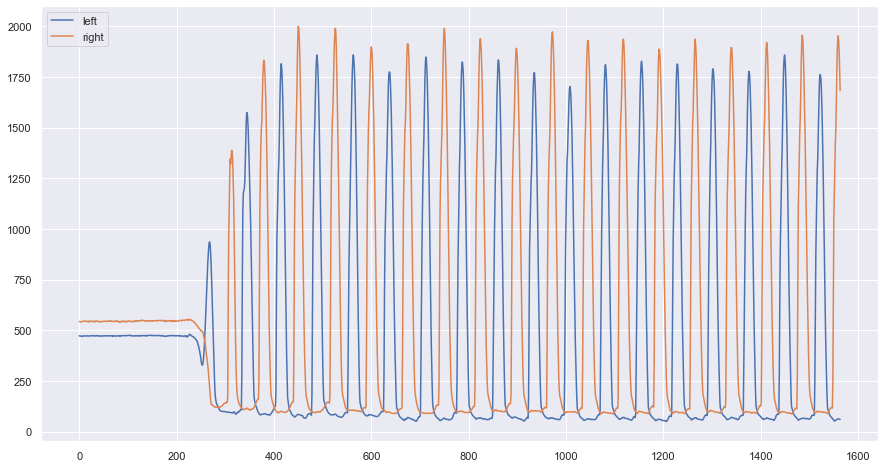

In [152]:
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [155]:
ic_right = pi_ic(force_right, 100)
ic_left = pi_ic(force_left, 100)

In [156]:
offset_l = force_left[ic_right[0]:ic_left[1]].mean() # offset during swing
offset_r = force_right[ic_left[1]:ic_right[1]].mean() # offset during swing

In [157]:
# remove offset
force_left = force_left-offset_l
force_right = force_right - offset_r

In [158]:
# filter < 20 N to 0
force_left[force_left<20]=0
force_right[force_right<20]=0

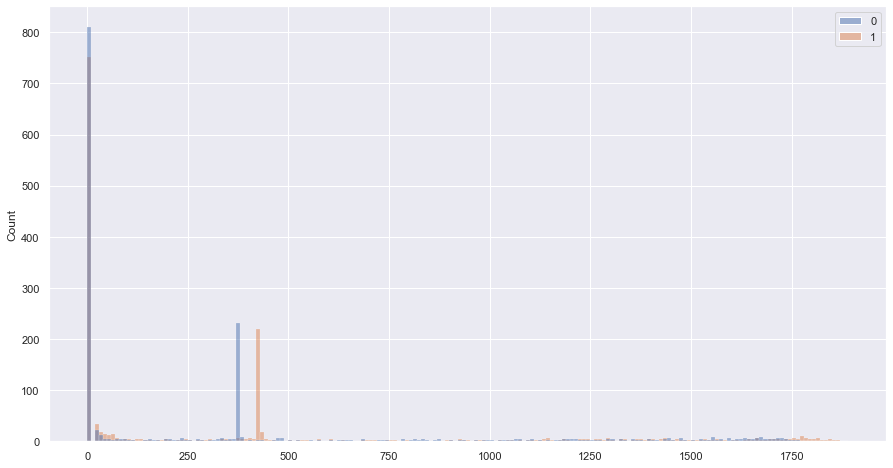

In [159]:
sns.histplot(data=[force_left, force_right], binwidth = 10)
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [160]:
d = pi_step_segmentation(force_left, force_right, 100)
d

{'IC_left': array([ 254,  333,  400,  477,  551,  625,  701,  775,  849,  922,  996,
        1070, 1143, 1217, 1290, 1364, 1437]),
 'IC_right': array([ 298,  362,  436,  507,  589,  663,  738,  812,  886,  960, 1033,
        1106, 1180, 1254, 1327, 1400, 1474]),
 'TO_left': array([ 287,  365,  432,  508,  580,  653,  728,  803,  877,  951, 1024,
        1097, 1170, 1245, 1318, 1391, 1464], dtype=int64),
 'TO_right': array([ 329,  398,  470,  545,  619,  694,  768,  844,  918,  991, 1064,
        1138, 1211, 1285, 1359, 1431, 1504], dtype=int64)}

In [161]:
def pi_temporal_parameters(pi_events_dict, sampling_rate_pi):
    """
    calculates Ground Contact Time, Flight Time, Stride Time
    :param pi_events_dict: Dict containing all IC and TO events
    :param sampling_rate_pi: sampling rate fs
    :return temp_params_df: Multiindex df with GCT, Flight T., Stride T., Side for all Steps
    """

    st_left = np.diff(pi_events_dict['IC_left'] / sampling_rate_pi, n=1)
    st_right = np.diff(pi_events_dict['IC_right'] / sampling_rate_pi, n=1)
    gct_left = (pi_events_dict['TO_left'] - pi_events_dict['IC_left']) / sampling_rate_pi
    gct_right = (pi_events_dict['TO_right'] - pi_events_dict['IC_right']) / sampling_rate_pi

    IC_all = np.sort(np.concatenate([pi_events_dict['IC_right'], pi_events_dict['IC_left']]))[1:]
    TO_all = np.sort(np.concatenate([pi_events_dict['TO_right'], pi_events_dict['TO_left']]))[:-1]
    ft = (IC_all - TO_all) / 100
    if pi_events_dict['IC_right'][0] < pi_events_dict['IC_left'][0]:
        ft_right_off = (IC_all - TO_all)[::2] / sampling_rate_pi
        ft_left_off = (IC_all - TO_all)[1::2] / sampling_rate_pi
    else:
        ft_left_off = (IC_all - TO_all)[::2] / sampling_rate_pi
        ft_right_off = (IC_all - TO_all)[1::2] / sampling_rate_pi

    cols = [np.repeat(['Stride Time [s]', 'Stance Time [s]', 'Flight Time [s]'], 2), np.tile(['left', 'right'], 3)]

    temp_params_df = pd.DataFrame([st_left, st_right, gct_left, gct_right, ft_left_off, ft_right_off], index=cols).T
    return temp_params_df

   Stride Time [s]       Stance Time [s]       Flight Time [s]      
              left right            left right            left right
0             0.79  0.64            0.33  0.31            0.11  0.04
1             0.67  0.74            0.32  0.36           -0.03  0.02
2             0.77  0.71            0.32  0.34            0.04  0.07
3             0.74  0.82            0.31  0.38           -0.01  0.06
4             0.74  0.74            0.29  0.30            0.09  0.06
5             0.76  0.75            0.28  0.31            0.10  0.07
6             0.74  0.74            0.27  0.30            0.10  0.07
7             0.74  0.74            0.28  0.32            0.09  0.05
8             0.73  0.74            0.28  0.32            0.09  0.04
9             0.74  0.73            0.29  0.31            0.09  0.05
10            0.74  0.73            0.28  0.31            0.09  0.06
11            0.73  0.74            0.27  0.32            0.09  0.05
12            0.74  0.74          

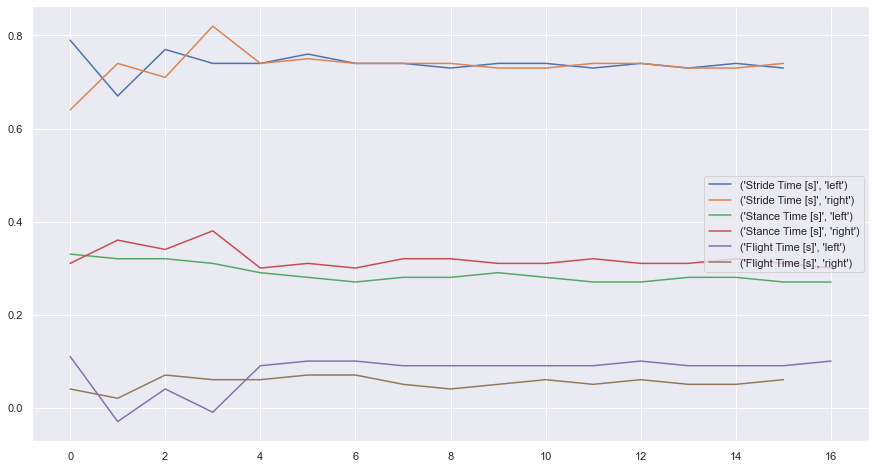

In [162]:
temp_df = pi_temporal_parameters(d, 100)
print(temp_df)
plt.plot(temp_df)
plt.legend(temp_df.columns)
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [165]:
steps = pi_separate_steps(left, right, d)

In [166]:
fpa = pi_get_fpa(steps, .82**2)

In [182]:
fpa_df = pi_dict_resample(fpa, 100)
fpa_df['Pressure'].describe().loc['min']

left_0      2.104750
left_1      2.070845
left_2      2.212964
left_3      1.914960
left_4      2.045294
left_5      2.189836
left_6      2.034266
left_7      2.073523
left_8      1.932807
left_9      1.945621
left_10     2.137480
left_11     2.144452
left_12     2.002829
left_13     2.063879
left_14     2.109979
left_15     1.993939
left_16     2.110722
right_0     1.995435
right_1     2.192471
right_2     2.191276
right_3     2.222961
right_4     2.225728
right_5     2.167858
right_6     2.090231
right_7     2.183059
right_8     2.151722
right_9     2.217665
right_10    2.193149
right_11    2.081243
right_12    2.200515
right_13    2.275767
right_14    2.162620
right_15    2.166015
right_16    2.229772
Name: min, dtype: float64

## Try filtering Pressure Matrix before processing

In [139]:
df = pd.read_csv(r'D:\Salzburg\julian_cutting_wedges\221122_pi_test\pi_jumpin2.csv')
left, right = separate_sides(df)

In [110]:
offset=np.min(left, axis=2)
for frame in range(left.shape[2]):
    left[:,:,frame]-=offset

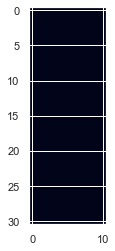

In [118]:
plt.imshow(np.min(left,axis=2))

In [140]:
offset = left[:,:,0]
for frame in range(1,left.shape[2]):
    if np.sum(offset)>np.sum(left[:,:,frame]):
        offset = left[:,:,frame]
for frame in range(left.shape[2]):
    left[:,:,frame]-=offset        
left[left<1]=0

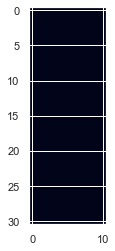

In [141]:
plt.imshow(np.min(left, axis=2))

In [131]:
np.sum(left[:,:,0])

461.44

In [130]:
np.sum(left, axis = 0).shape

(11, 1564)

In [145]:
left[left<2]=0
force_left = pi_force(left)
force_right = pi_force(right)

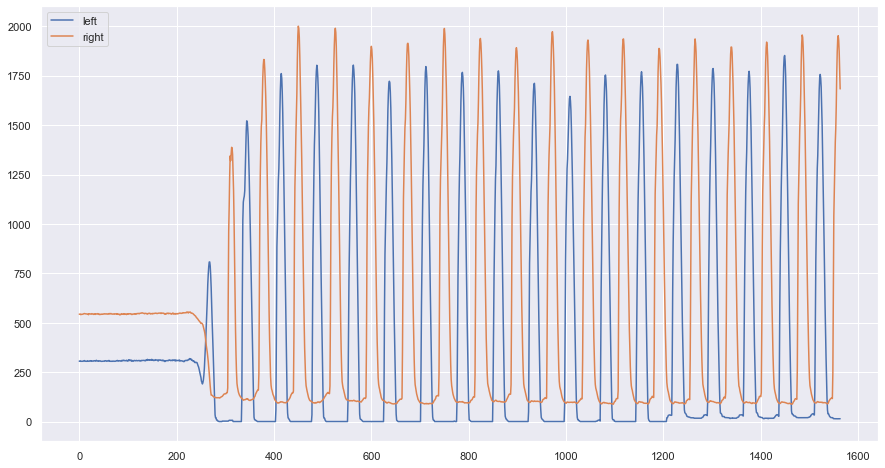

In [147]:
plt.plot(force_left[:], label='left')
plt.plot(force_right[:], label='right')
plt.legend()
#plt.ylim(0,100)
fig = plt.gcf()
fig.set_size_inches(15, 8)

In [ ]:
# get Contact Events
events_dict = pi_step_segmentation(force_left, force_right, 100) # sampling rate = 100 Hz?
events_dict

In [ ]:
events_dict['IC_left'][(events_dict['IC_left']<500) & (events_dict['IC_left'] > 20)]

In [ ]:
w1 = 0

In [ ]:
events_dict['TO_left']

In [ ]:
w2 = w1 + 400
forcer = force_right[w1:w2]
icr = events_dict['IC_right'][(events_dict['IC_right'] > w1) & (events_dict['IC_right'] < w2)]-w1
tor = events_dict['TO_right'][(events_dict['TO_right'] > w1) & (events_dict['TO_right'] < w2)]-w1
plt.plot(forcer)
plt.plot(icr, forcer[icr], 'x')
plt.plot(tor, force[tor], 'o')
fig = plt.gcf()
fig.set_size_inches(15, 8)
forcel = force_left[w1:w2]
icl = events_dict['IC_left'][(events_dict['IC_left'] > w1) & (events_dict['IC_left'] < w2)]-w1
tol = events_dict['TO_left'][(events_dict['TO_left'] > w1) & (events_dict['TO_left'] < w2)]-w1
plt.plot(forcel)
plt.plot(icl, forcer[icl], 'x')
plt.plot(tol, force[tol], 'o')

w1 += 200

In [ ]:
# find the hop 
print('left:', events_dict['IC_left'])
print('right:', events_dict['IC_right'])

In [ ]:
for i in range(len(events_dict['IC_left'])):
    if events_dict['IC_left'][i] & events_dict['IC_left'][i+1]<

In [ ]:
def find_hop(events_dict):
    if events_dict['IC_left'][0]<events_dict['IC_right'][0]:
        first = 'IC_left'
        second = 'IC_right'
    else:
        first = 'IC_right'
        second = 'IC_left'
    for i in range(20):
        if events_dict[first][i+1] < events_dict[second][i]:
            print('found hop at ' + str(i) + '. step '+ first[3:] + ' - index:' + str(events_dict[first][i]))
            return events_dict[first][i]
        elif events_dict[second][i] < events_dict[first][i]:
            print('found hop at ' + str(i) + '. step '+ second[3:] + ' - index: ' + str(events_dict[second][i]))
            return second, i


In [ ]:
#pi_step_segmentation(force_left, force_right, 100)['IC_left']
find_hop(d)


In [ ]:
d['IC_left'][5]

In [ ]:
d={'IC_left': events_dict['IC_right'][1:],
  'IC_right': events_dict['IC_left']}

In [ ]:
# separate Steps
steps_dict = pi_separate_steps(left, right, events_dict)

In [ ]:
# calculate COP
cop_dict = pi_get_cop(steps_dict)

In [ ]:
# calculate force, pressure, area dict
sensor_size = .82**2
fpa_dict = pi_get_fpa(steps_dict, sensor_size)
# resample to 100 samples per step & convert to Multiindex DF
whole_fpa_df = pi_dict_resample(fpa_dict, 100)

In [ ]:
whole_fpa_df

In [ ]:
# example step
ex = steps_dict['left_11']
# plot mean of example step
plt.imshow(np.mean(ex, axis=2), cmap='jet', interpolation='nearest')

In [ ]:
# create animation
fig, ax = plt.subplots()
ims=[]
for i in range(ex.shape[2]):
    im=ax.imshow(ex[:,:,0+i], animated=True, cmap='jet', interpolation='nearest')
    if i==0:
        ax.imshow(ex[:,:,0], cmap='jet', interpolation='nearest')
    ims.append([im])

ani=animation.ArtistAnimation(fig, ims, interval=26.6, blit=True, repeat_delay=10)